In [ ]:
#!pip install requests beautifulsoup4 pandas

In [3]:
# import necessary libraries
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

# define the base URL for scraping
base_url = "https://books.toscrape.com/catalogue/page-{}.html"

# create an empty list to store book data
books = []

# loop through the first 50 pages of the website
for page in range(1, 51):

    # construct the URL for the current page
    url = base_url.format(page)
    response = requests.get(url)

    # check if the request was successful
    if response.status_code == 200:

        # parse the HTML content of the page
        soup = BeautifulSoup(response.text, "html.parser")

        # loop through each book on the page
        for book in soup.select("article.product_pod"):

            # Basic information
            title = book.h3.a["title"]
            price = book.select_one(".price_color").text.strip()
            availability = book.select_one(".availability").text.strip()
            rating = book.select_one(".star-rating")["class"][1]

            # Book detail page URL
            book_url = "https://books.toscrape.com/catalogue/" + book.h3.a["href"]

            # Open individual book page
            book_response = requests.get(book_url)
            book_soup = BeautifulSoup(book_response.text, "html.parser")

            # Category
            category = book_soup.select("ul.breadcrumb li a")[-1].text.strip()

            # Number of reviews
            table = book_soup.select_one("table.table-striped")
            rows = table.select("tr")

            num_reviews = None

            # Loop through the rows of the table to find the number of reviews
            for row in rows:
                cells = row.select("td")

                if len(cells) == 2 and cells[0].text.strip() == "Number of reviews":
                    num_reviews = cells[1].text.strip()

            # Append the book data to the list
            books.append({
                "Name": title,
                "Price": price,
                "Rating": rating,
                "Availability": availability,
                "Category": category,
                "Number of Reviews": num_reviews,
                "URL": book_url
            })

        # Print a message indicating successful scraping of the page
        print(f"Page {page} scraped successfully")

    else:
        print(f"Error on page {page}: {response.status_code}")

    # Add a delay to avoid overwhelming the server
    time.sleep(0.5)

# Create a DataFrame from the list of books
df = pd.DataFrame(books)

# Save the DataFrame to a CSV file
df.to_csv("books_data.csv", index=False)



Page 1 scraped successfully
Page 2 scraped successfully
Page 3 scraped successfully
Page 4 scraped successfully
Page 5 scraped successfully
Page 6 scraped successfully
Page 7 scraped successfully
Page 8 scraped successfully
Page 9 scraped successfully
Page 10 scraped successfully
Page 11 scraped successfully
Page 12 scraped successfully
Page 13 scraped successfully
Page 14 scraped successfully
Page 15 scraped successfully
Page 16 scraped successfully
Page 17 scraped successfully
Page 18 scraped successfully
Page 19 scraped successfully
Page 20 scraped successfully
Page 21 scraped successfully
Page 22 scraped successfully
Page 23 scraped successfully
Page 24 scraped successfully
Page 25 scraped successfully
Page 26 scraped successfully
Page 27 scraped successfully
Page 28 scraped successfully
Page 29 scraped successfully
Page 30 scraped successfully
Page 31 scraped successfully
Page 32 scraped successfully
Page 33 scraped successfully
Page 34 scraped successfully
Page 35 scraped success

In [5]:
# Display the first few rows of the DataFrame
print(df.head())

                                    Name    Price Rating Availability  \
0                   A Light in the Attic  Â£51.77  Three     In stock   
1                     Tipping the Velvet  Â£53.74    One     In stock   
2                             Soumission  Â£50.10    One     In stock   
3                          Sharp Objects  Â£47.82   Four     In stock   
4  Sapiens: A Brief History of Humankind  Â£54.23   Five     In stock   

             Category Number of Reviews  \
0              Poetry              None   
1  Historical Fiction              None   
2             Fiction              None   
3             Mystery              None   
4             History              None   

                                                 URL  
0  https://books.toscrape.com/catalogue/a-light-i...  
1  https://books.toscrape.com/catalogue/tipping-t...  
2  https://books.toscrape.com/catalogue/soumissio...  
3  https://books.toscrape.com/catalogue/sharp-obj...  
4  https://books.toscrape.c

In [6]:
# Display the shape of the DataFrame
print(df.shape)

(1000, 7)


In [7]:
# Display the DataFrame
df

,Name,Price,Rating,Availability,Category,Number of Reviews,URL
0,A Light in the Attic,Â£51.77,Three,In stock,Poetry,None,https://books.toscrape.com/catalogue/a-light-i...
1,Tipping the Velvet,Â£53.74,One,In stock,Historical Fiction,None,https://books.toscrape.com/catalogue/tipping-t...
2,Soumission,Â£50.10,One,In stock,Fiction,None,https://books.toscrape.com/catalogue/soumissio...
3,Sharp Objects,Â£47.82,Four,In stock,Mystery,None,https://books.toscrape.com/catalogue/sharp-obj...
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock,History,None,https://books.toscrape.com/catalogue/sapiens-a...
...,...,...,...,...,...,...,...
995,Alice in Wonderland (Alice's Adventures in Won...,Â£55.53,One,In stock,Classics,None,https://books.toscrape.com/catalogue/alice-in-...
996,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",Â£57.06,Four,In stock,Sequential Art,None,https://books.toscrape.com/catalogue/ajin-demi...
997,A Spy's Devotion (The Regency Spies of London #1),Â£16.97,Five,In stock,Historical Fiction,None,https://books.toscrape.com/catalogue/a-spys-de...
998,1st to Die (Women's Murder Club #1),Â£53.98,One,In stock,Mystery,None,https://books.toscrape.com/catalogue/1st-to-di...


In [8]:
# Display information about the DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Name               1000 non-null   str   
 1   Price              1000 non-null   str   
 2   Rating             1000 non-null   str   
 3   Availability       1000 non-null   str   
 4   Category           1000 non-null   str   
 5   Number of Reviews  0 non-null      object
 6   URL                1000 non-null   str   
dtypes: object(1), str(6)
memory usage: 54.8+ KB


In [9]:
# Check for missing values in the DataFrame
df.isnull().sum()

Name                    0
Price                   0
Rating                  0
Availability            0
Category                0
Number of Reviews    1000
URL                     0
dtype: int64

In [10]:
# Rename the 'Name' column to 'Title'
df.rename(columns={'Name': 'Title'}, inplace=True)

In [11]:
# Display the 'Title' column
df.columns

Index(['Title', 'Price', 'Rating', 'Availability', 'Category',
       'Number of Reviews', 'URL'],
      dtype='str')

In [12]:
# check for duplicate titles
print("Duplicate titles:", df["Title"].duplicated().sum())

Duplicate titles: 1


In [13]:
# Drop duplicate titles
df = df.drop_duplicates(subset="Title")

In [14]:
# Display the shape of the DataFrame after removing duplicates
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (999, 7)


In [55]:
# Display the first few rows of the 'Price' column
print(df["Price"].head())

0    51.77
1    53.74
2    50.10
3    47.82
4    54.23
Name: Price, dtype: float64


In [16]:
# Convert the 'Price' column to float after removing the currency symbol
df["Price"] = (
    df["Price"]
    .astype(str)
    .str.replace("£", "", regex=False)
    .str.replace("Â", "", regex=False)
    .str.strip()
    .astype(float)
)

# Display the first few rows of the 'Price' column and its data type
print(df["Price"].head())
print(df["Price"].dtype)

0    51.77
1    53.74
2    50.10
3    47.82
4    54.23
Name: Price, dtype: float64
float64


In [17]:
# Display the value counts of the 'Rating' column
print(df["Rating"].value_counts())

Rating
One      226
Three    203
Two      196
Five     195
Four     179
Name: count, dtype: int64


In [18]:
# Map the textual ratings to numerical values
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating"] = df["Rating"].map(rating_map)

# Display the first few rows of the 'Rating' column
print(df["Rating"].head())

0    3
1    1
2    1
3    4
4    5
Name: Rating, dtype: int64


In [ ]:
# Display the first few rows of the 'Availability' column
print(df["Availability"].head(10))

0    In stock
1    In stock
2    In stock
3    In stock
4    In stock
5    In stock
6    In stock
7    In stock
8    In stock
9    In stock
Name: Availability, dtype: str


In [21]:
print(df["Availability"].unique())

<StringArray>
['In stock']
Length: 1, dtype: str


In [32]:
df["Stock Status"] = df["Availability"].apply(
    lambda x: "In Stock" if str(x).strip().lower() == "in stock"
    else "Out of Stock"
)

print(df[["Availability", "Stock Count", "Stock Status"]].head())

  Availability  Stock Count Stock Status
0     In stock          NaN     In Stock
1     In stock          NaN     In Stock
2     In stock          NaN     In Stock
3     In stock          NaN     In Stock
4     In stock          NaN     In Stock


In [33]:
# identify text columns in the DataFrame
text_columns = df.select_dtypes(include="object").columns

print(text_columns)

Index(['Title', 'Availability', 'Category', 'Number of Reviews', 'URL',
       'Stock Status'],
      dtype='str')


C:\Users\rohit\AppData\Local\Temp\ipykernel_19824\3705007992.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include="object").columns


In [34]:
# Clean text columns by removing extra whitespace and stripping leading/trailing spaces
for col in text_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

In [35]:
# remove rows with missing values in required columns
required_columns = [
    "Title",
    "Price",
    "Rating",
    "Availability"
]

df = df.dropna(subset=required_columns)

print(df.shape)

(999, 11)


In [36]:
# make sure numerical columnd have the correct data type
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")
df["Stock Count"] = pd.to_numeric(df["Stock Count"], errors="coerce")

print(df[["Price", "Rating", "Stock Count"]].dtypes)

Price          float64
Rating           int64
Stock Count    float64
dtype: object


In [37]:
# create a new column 'Price Range' based on the 'Price' column
df["Price Range"] = pd.cut(
    df["Price"],
    bins=[0, 20, 40, 60, float("inf")],
    labels=["Low", "Medium", "High", "Very High"]
)

print(df[["Price", "Price Range"]].head())

   Price Price Range
0  51.77        High
1  53.74        High
2  50.10        High
3  47.82        High
4  54.23        High


In [38]:
# create rating group based on the 'Rating' column
df["Rating Group"] = pd.cut(
    df["Rating"],
    bins=[0, 2, 3, 4, 5],
    labels=["Low", "Average", "Good", "Excellent"]
)

print(df[["Rating", "Rating Group"]].head())

   Rating Rating Group
0       3      Average
1       1          Low
2       1          Low
3       4         Good
4       5    Excellent


In [39]:
# create a new column 'Stock Status' based on the 'Stock Count' column
df["Stock Status"] = df["Stock Count"].apply(
    lambda x: "In Stock" if pd.notna(x) and x > 0
    else "Out of Stock" if pd.notna(x) and x == 0
    else "Unknown"
)

print(df[["Stock Count", "Stock Status"]].head())

   Stock Count Stock Status
0          NaN      Unknown
1          NaN      Unknown
2          NaN      Unknown
3          NaN      Unknown
4          NaN      Unknown


In [47]:
df["Stock Status"] = df["Availability"].apply(
    lambda x: "In Stock" if str(x).strip().lower() == "in stock"
    else "Out of Stock"
)
print(df["Stock Status"].value_counts())

Stock Status
In Stock    999
Name: count, dtype: int64


In [48]:
# finally, display the cleaned and processed DataFrame
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nDuplicate titles:")
print(df["Title"].duplicated().sum())

                                   Title  Price  Rating Availability  \
0                   A Light in the Attic  51.77       3     In stock   
1                     Tipping the Velvet  53.74       1     In stock   
2                             Soumission  50.10       1     In stock   
3                          Sharp Objects  47.82       4     In stock   
4  Sapiens: A Brief History of Humankind  54.23       5     In stock   

             Category Number of Reviews  \
0              Poetry               NaN   
1  Historical Fiction               NaN   
2             Fiction               NaN   
3             Mystery               NaN   
4             History               NaN   

                                                 URL  Stock Count  \
0  https://books.toscrape.com/catalogue/a-light-i...          NaN   
1  https://books.toscrape.com/catalogue/tipping-t...          NaN   
2  https://books.toscrape.com/catalogue/soumissio...          NaN   
3  https://books.toscrape.com/ca

In [ ]:
# final checks and summary of the DataFrame
print("Shape:", df.shape)

print("\nDuplicate titles:")
print(df["Title"].duplicated().sum())

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Shape: (999, 11)

Duplicate titles:
0

Missing values:
Title                  0
Price                  0
Rating                 0
Availability           0
Category               0
Number of Reviews    999
URL                    0
Stock Count          999
Stock Status           0
Price Range            0
Rating Group           0
dtype: int64

Data types:
Title                     str
Price                 float64
Rating                  int64
Availability              str
Category                  str
Number of Reviews         str
URL                       str
Stock Count           float64
Stock Status              str
Price Range          category
Rating Group         category
dtype: object


In [50]:
# Save the cleaned dataset to a new CSV file
df.to_csv("books_data_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


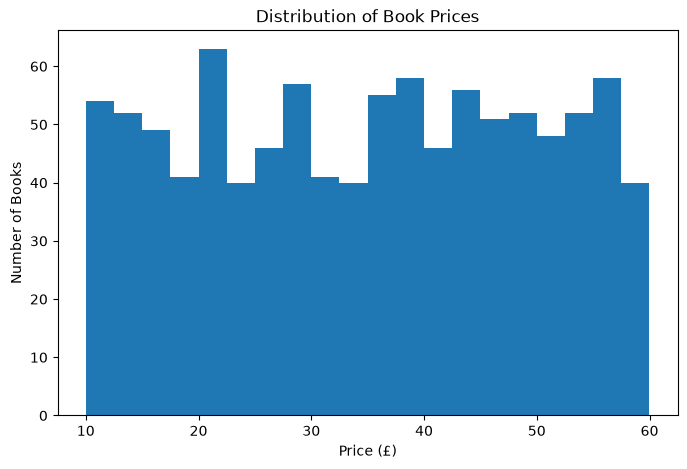

In [64]:
# What is the distribution of book prices

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df["Price"], bins=20)

plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.title("Distribution of Book Prices")

plt.show()

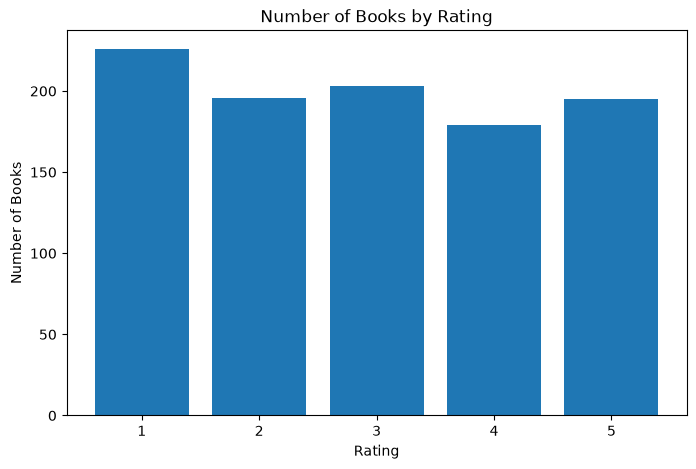

In [65]:
# Number of Books by Rating

import matplotlib.pyplot as plt

rating_counts = df["Rating"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(rating_counts.index, rating_counts.values)

plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.title("Number of Books by Rating")

plt.xticks([1, 2, 3, 4, 5])

plt.show()

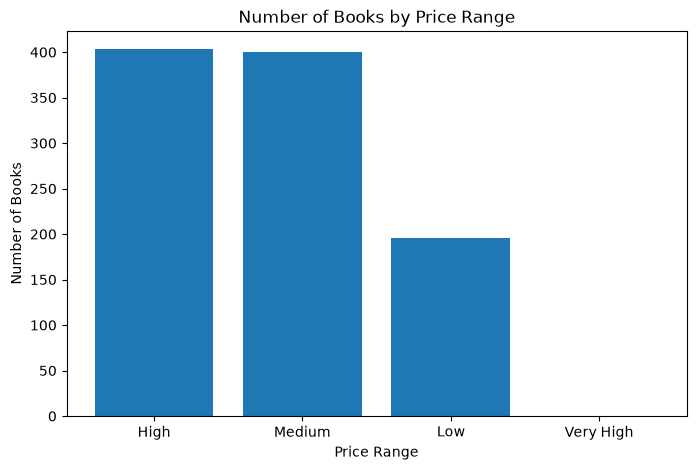

In [66]:
# Number of Books by Price Range

import matplotlib.pyplot as plt

price_range_counts = df["Price Range"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(price_range_counts.index.astype(str), price_range_counts.values)

plt.xlabel("Price Range")
plt.ylabel("Number of Books")
plt.title("Number of Books by Price Range")

plt.show()

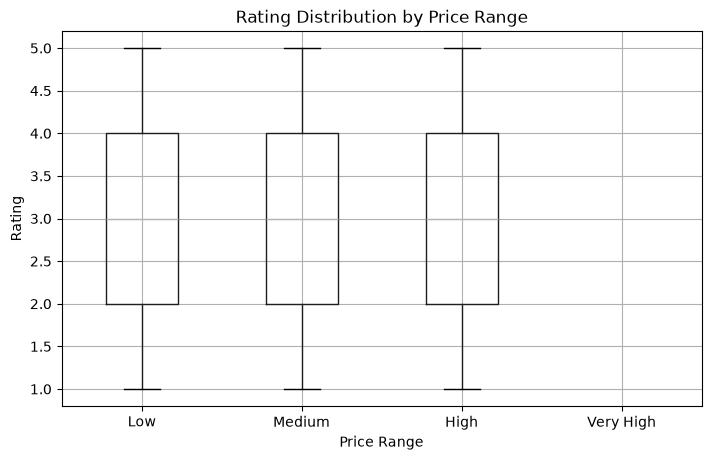

In [67]:
# Rating Distribution by Price Range

import matplotlib.pyplot as plt

df.boxplot(
    column="Rating",
    by="Price Range",
    figsize=(8, 5)
)

plt.xlabel("Price Range")
plt.ylabel("Rating")
plt.title("Rating Distribution by Price Range")
plt.suptitle("")

plt.show()

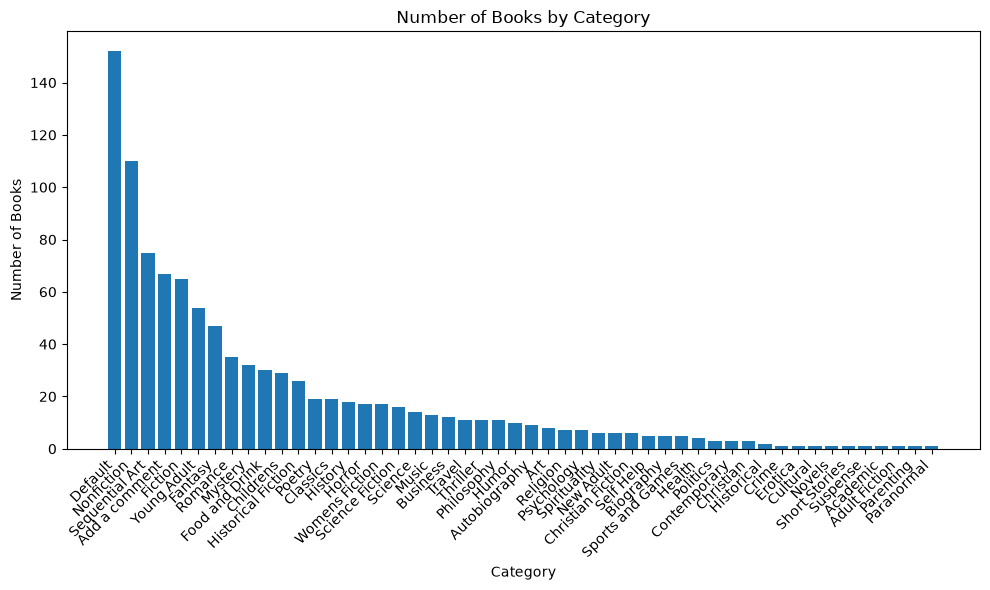

In [68]:
# Number of Books by Category

import matplotlib.pyplot as plt

category_counts = df["Category"].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(category_counts.index, category_counts.values)

plt.xlabel("Category")
plt.ylabel("Number of Books")
plt.title("Number of Books by Category")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

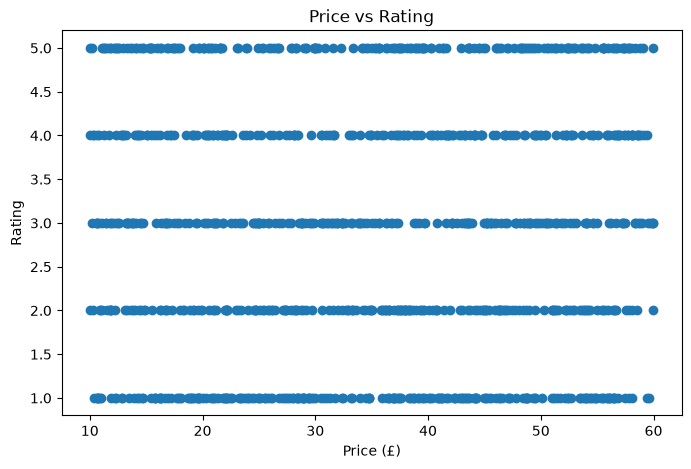

In [69]:
# Price vs Rating

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(df["Price"], df["Rating"])

plt.xlabel("Price (£)")
plt.ylabel("Rating")
plt.title("Price vs Rating")

plt.show()

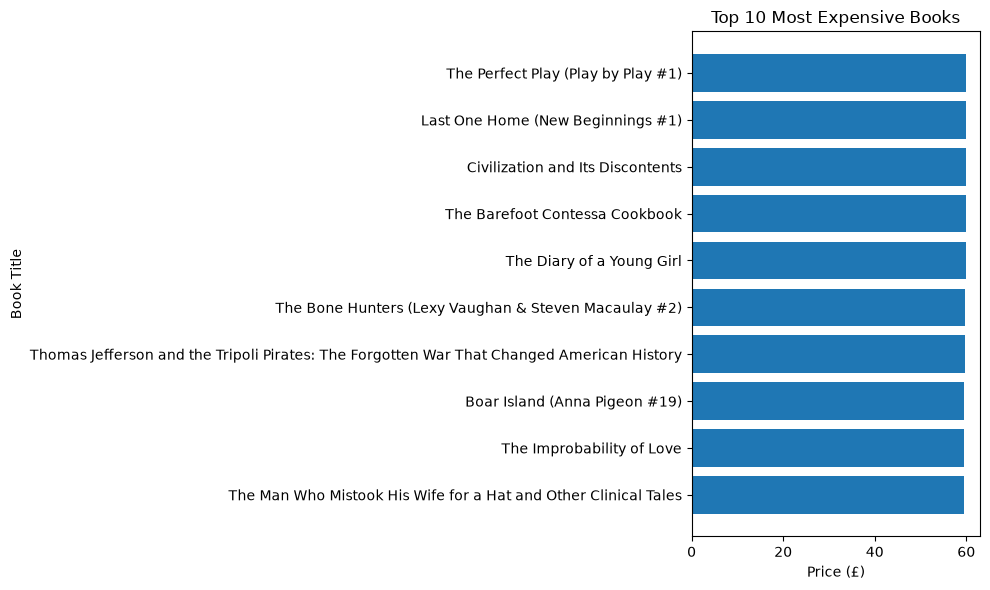

In [70]:
# Top 10 Most Expensive Books

top_10_expensive = df.nlargest(10, "Price")

plt.figure(figsize=(10, 6))

plt.barh(top_10_expensive["Title"], top_10_expensive["Price"])

plt.xlabel("Price (£)")
plt.ylabel("Book Title")
plt.title("Top 10 Most Expensive Books")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

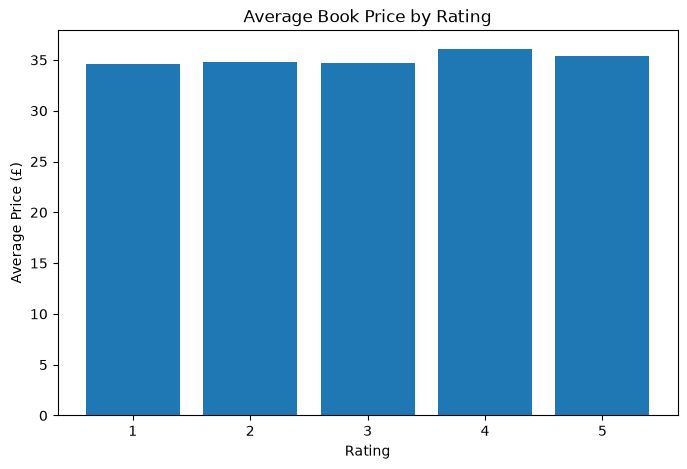

In [71]:
# Average Price by Rating
import matplotlib.pyplot as plt

avg_price_by_rating = df.groupby("Rating", observed=True)["Price"].mean()

plt.figure(figsize=(8, 5))

plt.bar(avg_price_by_rating.index, avg_price_by_rating.values)

plt.xlabel("Rating")
plt.ylabel("Average Price (£)")
plt.title("Average Book Price by Rating")

plt.xticks([1, 2, 3, 4, 5])

plt.show()

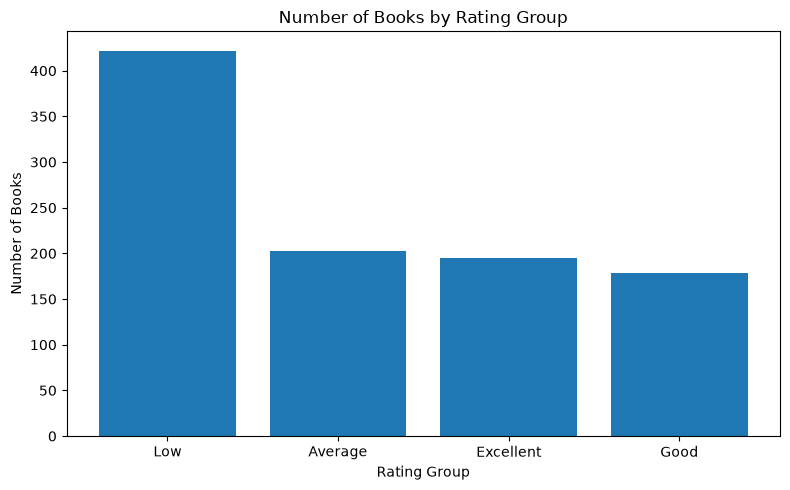

In [72]:
# Number of Books in Each Rating Group

import matplotlib.pyplot as plt

rating_group_counts = df["Rating Group"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    rating_group_counts.index.astype(str),
    rating_group_counts.values
)

plt.xlabel("Rating Group")
plt.ylabel("Number of Books")
plt.title("Number of Books by Rating Group")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

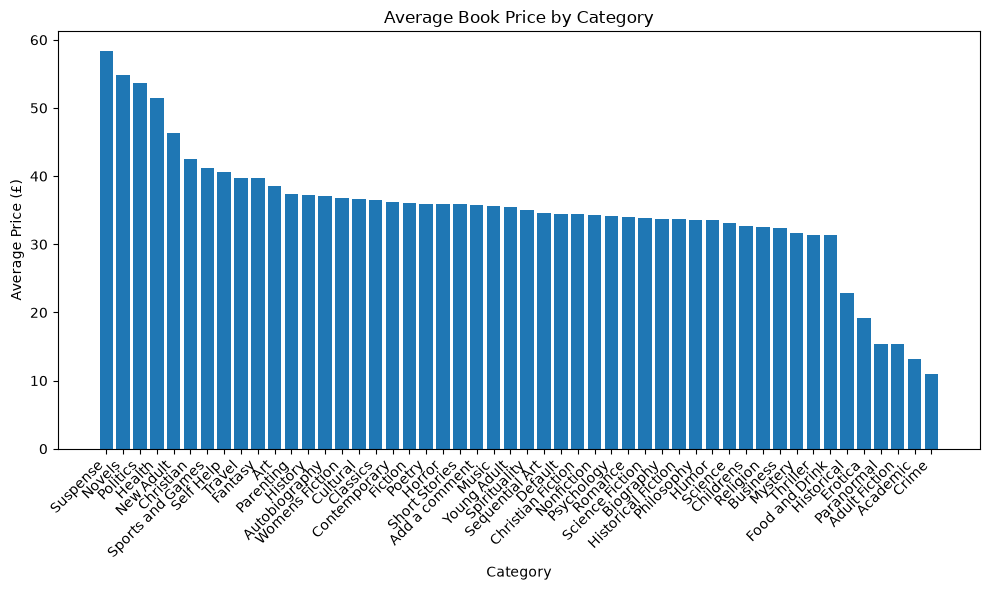

In [73]:
# Average Price by Category

import matplotlib.pyplot as plt

avg_price_category = (
    df.groupby("Category", observed=True)["Price"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    avg_price_category.index,
    avg_price_category.values
)

plt.xlabel("Category")
plt.ylabel("Average Price (£)")
plt.title("Average Book Price by Category")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()